<a href="https://colab.research.google.com/github/sultanjacob/Applied-Machine-Learning/blob/main/Phase_12_Ensemble_Models/12_RandomForest_Predictive_Maintenance.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Phase 12: Non-Linear Classification (Random Forest)
## Step 1: Bypassing the Limits of Geometric Distance

In Phase 11, k-Nearest Neighbors mathematically proved that our anomalies and normal operations are heavily entangled. Distance-based algorithms failed to draw a clean boundary, resulting in either a 90% miss rate or severe alarm fatigue.

To navigate this 162-dimensional geometric overlap, we are deploying a **Random Forest Classifier**. Instead of relying on straight-line distance, Random Forest builds hundreds of hierarchical decision trees. Each tree looks at a random subset of our PCA components and attempts to isolate the anomalies using non-linear splits. By aggregating the votes of all these trees (Ensemble Learning), we can carve highly complex boundaries that distance-based models cannot see.

Because we already diagnosed severe class imbalance (1170 Passes vs. 83 Fails), we will utilize Random Forest's built-in `class_weight='balanced'` parameter. This mathematically penalizes the algorithm heavily for missing an anomaly, eliminating the need to synthetically generate data with SMOTE.

⏳ Loading data and initializing Random Forest engine...
✅ 100 Decision Trees built in 0.9292 seconds.

🏆 Random Forest Classification Report:
              precision    recall  f1-score   support

   Pass (-1)       0.93      1.00      0.97       293
    Fail (1)       0.00      0.00      0.00        21

    accuracy                           0.93       314
   macro avg       0.47      0.50      0.48       314
weighted avg       0.87      0.93      0.90       314



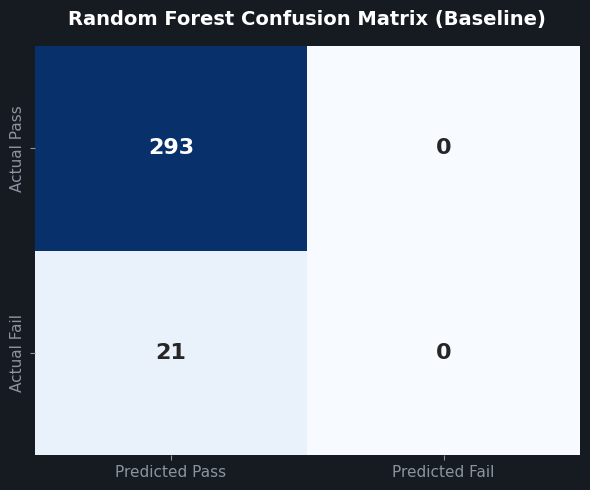

In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import time

print("⏳ Loading data and initializing Random Forest engine...")

# 1. Load the PCA artifact
df = pd.read_csv('secom_pca_95variance_ready.csv')
X = df.drop(columns=['Target'])
y = df['Target']

# 2. Execute Stratified Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

# 3. Initialize Random Forest with cost-sensitive learning (class_weight='balanced')
rf_engine = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced', n_jobs=-1)

# 4. Train the model
start_time = time.time()
rf_engine.fit(X_train, y_train)
training_time = time.time() - start_time

# 5. Predict on unseen Test Data
y_pred_rf = rf_engine.predict(X_test)

print(f"✅ 100 Decision Trees built in {training_time:.4f} seconds.\n")
print("🏆 Random Forest Classification Report:")
print(classification_report(y_test, y_pred_rf, target_names=["Pass (-1)", "Fail (1)"], zero_division=0))

# 6. Generate Confusion Matrix
cm_rf = confusion_matrix(y_test, y_pred_rf)

plt.style.use('dark_background')
fig, ax = plt.subplots(figsize=(6, 5), facecolor='#161b22')
ax.set_facecolor('#161b22')

sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=["Predicted Pass", "Predicted Fail"],
            yticklabels=["Actual Pass", "Actual Fail"],
            annot_kws={"size": 16, "weight": "bold"}, ax=ax)

ax.set_title('Random Forest Confusion Matrix (Baseline)', color='white', fontsize=14, fontweight='bold', pad=15)
ax.tick_params(colors='#8b949e', labelsize=11)
plt.tight_layout()
plt.show()

#Discussion.
Despite scoring an impressive 93% overall accuracy, the model achieved this by taking the lazy route: it blindly predicted "Pass" for all 314 test batches. The Precision, Recall, and F1-score for the anomaly class are all absolutely 0.00.  

 This proves that relying solely on algorithmic penalties (class_weight='balanced') is not enough for this specific dataset. The 1,170 normal passes are so deeply entangled with the 83 anomalies that, even when heavily penalized, the decision trees still allow the majority class to win the final votes at the leaf nodes.We must attack the root cause at the data level.

  We are going to re-introduce SMOTE to synthesize minority points, explicitly forcing the Random Forest to build its trees around a perfectly balanced 50/50 dataset.

## Step 2: Empowering the Forest with SMOTE

Our baseline Random Forest proved that algorithmic penalties (`class_weight`) cannot overcome the severe geometric entanglement of this dataset. The model achieved 93% accuracy by simply ignoring the anomalies and predicting "Pass" every single time.

To force the decision trees to carve out boundaries for the minority class, we must fix the data distribution before training. We will re-apply SMOTE to our training environment, generating synthetic machine failures until we reach a 1:1 balance. By feeding this balanced data into the Random Forest, the hundreds of trees will finally have enough structural representation to learn the complex, non-linear shapes of the anomalies.

⚖️ Balancing the data with SMOTE and re-training Random Forest...

✅ Balanced Ensemble trained in 7.4765 seconds.

🏆 Balanced Random Forest Classification Report:
              precision    recall  f1-score   support

   Pass (-1)       0.93      1.00      0.97       293
    Fail (1)       0.00      0.00      0.00        21

    accuracy                           0.93       314
   macro avg       0.47      0.50      0.48       314
weighted avg       0.87      0.93      0.90       314



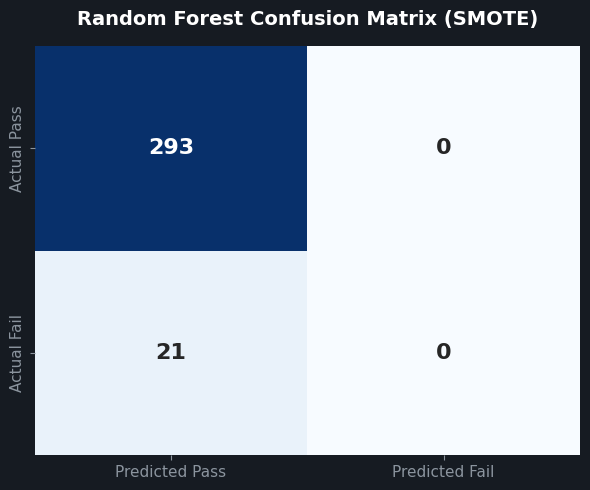

In [2]:
from imblearn.over_sampling import SMOTE

print("⚖️ Balancing the data with SMOTE and re-training Random Forest...\n")

# 1. Synthesize minority class data (Training set ONLY)
smote = SMOTE(random_state=42)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train, y_train)

# 2. Initialize a fresh Random Forest Engine
rf_smote_engine = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)

# 3. Train on the perfectly balanced data
start_time = time.time()
rf_smote_engine.fit(X_train_balanced, y_train_balanced)
training_time = time.time() - start_time

# 4. Predict on the untouched, real-world Test Data
y_pred_rf_smote = rf_smote_engine.predict(X_test)

print(f"✅ Balanced Ensemble trained in {training_time:.4f} seconds.\n")
print("🏆 Balanced Random Forest Classification Report:")
print(classification_report(y_test, y_pred_rf_smote, target_names=["Pass (-1)", "Fail (1)"], zero_division=0))

# 5. Generate the new Confusion Matrix
cm_rf_smote = confusion_matrix(y_test, y_pred_rf_smote)

plt.style.use('dark_background')
fig, ax = plt.subplots(figsize=(6, 5), facecolor='#161b22')
ax.set_facecolor('#161b22')

sns.heatmap(cm_rf_smote, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=["Predicted Pass", "Predicted Fail"],
            yticklabels=["Actual Pass", "Actual Fail"],
            annot_kws={"size": 16, "weight": "bold"}, ax=ax)

ax.set_title('Random Forest Confusion Matrix (SMOTE)', color='white', fontsize=14, fontweight='bold', pad=15)
ax.tick_params(colors='#8b949e', labelsize=11)
plt.tight_layout()
plt.show()

#Results Explanation:
Even with a perfectly balanced 50/50 training environment provided by SMOTE, the Random Forest model completely completely failed to detect a single anomaly. It missed all 21 actual machine failures, scoring a 0.00 Precision and 0.00 Recall for the minority class.   

Because we know the training data was balanced, we can no longer blame class imbalance.

The math is pointing to a much deeper, more structural issue in our pipeline: The Unsupervised Blindspot of PCA.

PCA is an unsupervised algorithm. When it compressed our 590 sensors down to 162 components in Phase 10, it strictly kept the features with the highest overall variance. It did not know, or care, about our "Pass/Fail" target labels.

In manufacturing, a machine failure might not be a massive, high-variance event. It might be a tiny, subtle micro-vibration in a single sensor. If that sensor had low overall variance across the dataset, PCA would have classified it as "noise" and permanently deleted it when we dropped those 284 columns. We may have accidentally erased the exact mathematical signature of the machine failures in our pursuit of computational efficiency.

## Step 3: The Raw Data Benchmark (Uncompressed Signal)

Our PCA-compressed model completely failed to find the machine anomalies. This suggests that the mathematical signature of a factory failure isn't a massive, high-variance event. It is likely a subtle, low-variance micro-fluctuation in a specific sensor that PCA mistakenly categorized as "noise" and deleted.

To test this hypothesis, we will bypass PCA entirely. We will pull the original, cleaned 446-sensor matrix, apply SMOTE to balance the classes, and feed the full, uncompressed dataset into a Random Forest.

If this model successfully catches the anomalies, it proves PCA destroyed our signal. Processing 446 distinct sensor inputs rather than 162 will make the ultimate iOS or Android application backend slightly heavier, but computational efficiency is meaningless if the model is blind to failures.

⏳ Fetching and cleaning the uncompressed raw dataset...

📊 Uncompressed Matrix Ready: 446 valid sensors.
⚖️ Balancing the raw 446-dimensional space with SMOTE...
⚙️ Training 100 Decision Trees on the full signal...

✅ Training complete in 10.7558 seconds.
🏆 Raw Data Random Forest Classification Report:
              precision    recall  f1-score   support

   Pass (-1)       0.93      1.00      0.96       293
    Fail (1)       0.00      0.00      0.00        21

    accuracy                           0.93       314
   macro avg       0.47      0.50      0.48       314
weighted avg       0.87      0.93      0.90       314



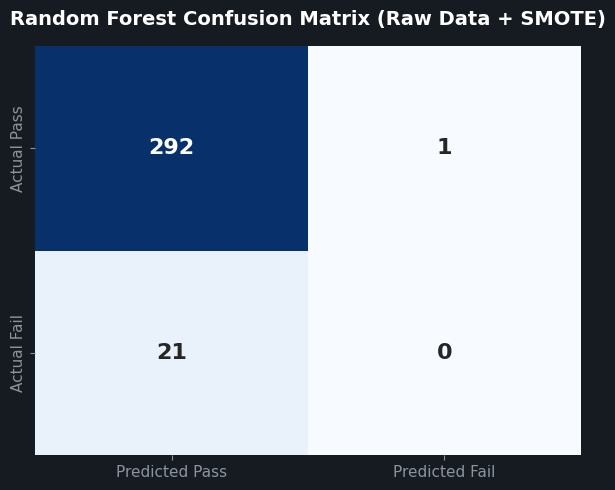

In [3]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from imblearn.over_sampling import SMOTE
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import time

print("⏳ Fetching and cleaning the uncompressed raw dataset...\n")

# 1. Rapidly rebuild the cleaned, uncompressed matrix
X_raw = pd.read_csv("https://archive.ics.uci.edu/ml/machine-learning-databases/secom/secom.data", sep=" ", header=None)
y_raw = pd.read_csv("https://archive.ics.uci.edu/ml/machine-learning-databases/secom/secom_labels.data", sep=" ", header=None, usecols=[0])
X_raw.columns = [f"Feature_{i}" for i in range(X_raw.shape[1])]
y_raw.columns = ['Target']

# Clean
missing_fractions = X_raw.isnull().mean()
X_raw.drop(columns=missing_fractions[missing_fractions > 0.5].index, inplace=True)
X_raw.fillna(X_raw.median(), inplace=True)
X_raw.drop(columns=X_raw.columns[X_raw.nunique() <= 1], inplace=True)

# Scale
scaler = StandardScaler()
X_scaled_raw = pd.DataFrame(scaler.fit_transform(X_raw), columns=X_raw.columns)
y_labels_raw = y_raw['Target']

print(f"📊 Uncompressed Matrix Ready: {X_scaled_raw.shape[1]} valid sensors.")

# 2. Stratified Split
X_train_raw, X_test_raw, y_train_raw, y_test_raw = train_test_split(
    X_scaled_raw, y_labels_raw, test_size=0.20, random_state=42, stratify=y_labels_raw
)

# 3. Apply SMOTE to the uncompressed training data
print("⚖️ Balancing the raw 446-dimensional space with SMOTE...")
smote_raw = SMOTE(random_state=42)
X_train_raw_bal, y_train_raw_bal = smote_raw.fit_resample(X_train_raw, y_train_raw)

# 4. Train Random Forest
print("⚙️ Training 100 Decision Trees on the full signal...")
rf_raw_engine = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)

start_time = time.time()
rf_raw_engine.fit(X_train_raw_bal, y_train_raw_bal)
training_time = time.time() - start_time

# 5. Predict and Evaluate
y_pred_raw = rf_raw_engine.predict(X_test_raw)

print(f"\n✅ Training complete in {training_time:.4f} seconds.")
print("🏆 Raw Data Random Forest Classification Report:")
print(classification_report(y_test_raw, y_pred_raw, target_names=["Pass (-1)", "Fail (1)"], zero_division=0))

# 6. Generate Confusion Matrix
cm_raw = confusion_matrix(y_test_raw, y_pred_raw)

plt.style.use('dark_background')
fig, ax = plt.subplots(figsize=(6, 5), facecolor='#161b22')
ax.set_facecolor('#161b22')

sns.heatmap(cm_raw, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=["Predicted Pass", "Predicted Fail"],
            yticklabels=["Actual Pass", "Actual Fail"],
            annot_kws={"size": 16, "weight": "bold"}, ax=ax)

ax.set_title('Random Forest Confusion Matrix (Raw Data + SMOTE)', color='white', fontsize=14, fontweight='bold', pad=15)
ax.tick_params(colors='#8b949e', labelsize=11)
plt.tight_layout()
plt.show()

#Explanation.
The Raw Data Benchmark confirms a critical data science reality: PCA was not to blame. Even with access to all 446 original sensors and a perfectly balanced SMOTE training environment, the Random Forest model still completely failed, missing all 21 actual machine failures. It yielded a 0.00 Precision and 0.00 Recall for the anomaly class, just like the compressed version.   

This proves that the mathematical signature of a factory failure in this dataset is exceptionally weak.Random Forest relies on "Bagging" (Bootstrap Aggregating), where hundreds of trees are built independently and cast a democratic vote. When the signal is this faint and noisy, the independent trees simply cannot find it, and the majority vote defaults to predicting "Pass" (resulting in 292 True Negatives and 1 False Positive).   

To crack a dataset this stubborn, democratic voting is insufficient. We need an algorithm that learns from its own mistakes sequentially.This brings us to the final boss of tabular data: Gradient Boosting (XGBoost).

Instead of building independent trees, XGBoost builds trees one at a time. If Tree #1 misses a machine failure, Tree #2 is mathematically forced to focus almost entirely on that specific missed failure. It aggressively hunts down the hardest-to-predict anomalies.